# FD001 Exploratory Data Analysis

## Objective

Explore the structure, engine lifetime, operating settings, and sensor measurements in NASA's C-MAPSS training dataset

The dataset represents simulated aircraft turbofan engines.

In [31]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data.load_data import load_cmapss_file
from src.data.validate_data import validate_cmapss_data

Path.cwd()

WindowsPath('F:/Projects/energy-predictive-maintenance/notebooks')

In [32]:
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "cmapss" / "train_FD001.txt"

print(DATA_PATH)
print(DATA_PATH.exists())

F:\Projects\energy-predictive-maintenance\data\raw\cmapss\train_FD001.txt
True


In [33]:
data = load_cmapss_file(DATA_PATH)

validate_cmapss_data(data)

print(f"Rows: {data.shape[0]}")
print(f"Columns: {data.shape[1]}")

Rows: 20631
Columns: 26


## Engine lifetime analysis

Each row represents one engine at one operating cycle. For each engine, its maximum cycle number represents its complete observed lifetime before failure

In [34]:
print(data.columns.to_list())

print(data.head(5))

pd.set_option("display.max_columns", None)
print(data.dtypes)

['unit_number', 'time_in_cycles', 'operational_setting_1', 'operational_setting_2', 'operational_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']
   unit_number  time_in_cycles  operational_setting_1  operational_setting_2  \
0            1               1                -0.0007                -0.0004   
1            1               2                 0.0019                -0.0003   
2            1               3                -0.0043                 0.0003   
3            1               4                 0.0007                 0.0000   
4            1               5                -0.0019                -0.0002   

   operational_setting_3  sensor_1  sensor_2  sensor_3  sensor_4  sensor_5  \
0                  100.0    518.67    641.82   1589.70   1400.60    

In [35]:
engine_lifetimes = (
    data.groupby("unit_number")["time_in_cycles"].max()
)

print(f"Number of engines: {data['unit_number'].nunique()}")

engine_lifetimes.describe()

Number of engines: 100


count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: time_in_cycles, dtype: float64

### FD001 Training-Set Observations

- This training set contains ***100 engine units***
- The shortest recorded engine trajectory contains ***128 cycles***
- The longest recorded trajectory contains ***362 cycles***
- The median recorded trajectory length is ***199 cycles***
- The mean recorded trajectory length is approximately ***206.31 cycles***
- The middle 50% of the recorded trajectories range from ***177 to 229.25 cycles***
- Because the mean is higher than the median, the distributions appears slightly right-skewed: a small number of longer trajectories increase the average

### Distribution of enine lifetimes

This chart shows how the observed run-to-failure cycle counts vary across the 100 engines in FD001.

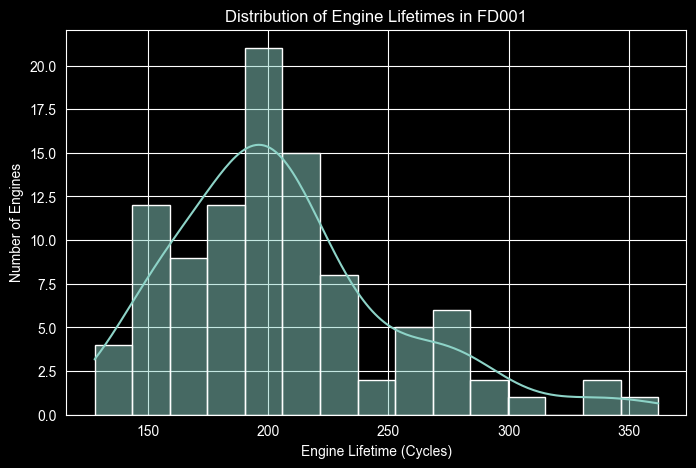

In [36]:
# KDE curve helps us to identify:
# Where engine lifetimes are most concentrated
# Whether the distribution is symmetric or skewed
# Whether there may be multiple peaks


fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    data= engine_lifetimes,
    bins=15,
    kde=True,
    ax=ax
)

ax.set_title("Distribution of Engine Lifetimes in FD001")
ax.set_xlabel("Engine Lifetime (Cycles)")
ax.set_ylabel("Number of Engines")

plt.show()

**Observations**
- Most FD001 engine lifetimes are concentrated between approximately 150 and 230 cycles
- The highest concentration occurs near 190-210 cycles
- The distribution is right-skewed, with a small number of engines operating for more than 300 cycles
- These results describe simulated C-MAPSS aircraft turbofan trajectories and should not be interpreted as expected lifetimes for real energy-sector equipment.

## Operating settings

In [37]:
# .T stands for transpose
operating_setting_columns = [
    "operational_setting_1",
    "operational_setting_2",
    "operational_setting_3"
]

data[operating_setting_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
operational_setting_1,20631.0,-0.000009,0.002187,-0.0087,-0.0015,0.0,0.0015,0.0087
operational_setting_2,20631.0,0.000002,0.000293,-0.0006,-0.0002,0.0,0.0003,0.0006
operational_setting_3,20631.0,100.000000,0.000000,100.0000,100.0000,100.0,100.0000,100.0000


In [38]:
data[operating_setting_columns].nunique()

operational_setting_1    158
operational_setting_2     13
operational_setting_3      1
dtype: int64

**Observations**
- The first 2 operating settings vary within narrow ranges around zero.
- The third operating setting is constant at 100 for every observation.
- The operating-setting columns show little variation across the FD001 dataset. This is expected because FD01 represents a single operating condition rather than multiple operating environment.
- The constant third setting is unlikely to provide predictive information within FD001, but feature removal will be considered later during feature engineering rather than performed during exploration.

## Sensor variability
#### Determine which sensors change and which are constant or nearly constant

In [39]:
# unique_values: how many different measurements each sensor contains
# standard_deviation: how much each sensor varies

sensor_columns = [
    f"sensor_{number}" for number in range (1,22)
]

sensor_summary = pd.DataFrame(
    {
        "unique_values": data[sensor_columns].nunique(),
        "standard_deviation":data[sensor_columns].std()
    }
)

sensor_summary = sensor_summary.sort_values("standard_deviation")

display(sensor_summary)

,unique_values,standard_deviation
sensor_1,1,0.000000e+00
sensor_10,1,0.000000e+00
sensor_19,1,0.000000e+00
sensor_18,1,0.000000e+00
sensor_16,1,1.387812e-17
sensor_5,1,1.776400e-15
sensor_6,2,1.388985e-03
sensor_15,1918,3.750504e-02
sensor_8,53,7.098548e-02
sensor_13,56,7.191892e-02


**Observations**
- Sensor 1,5,10,16,18, and 19 are constant across FD001
- Constant: have the same recorded value in every row of the FD001 dataset
- Sensor 6 is nearly constant, having 2 distinct values
- Standard deviations cannot be compared as measures of predictive importance because the sensors use different numerical scales and physical units

## Sensor behavior over operating cycles

The following chart compares sensor 11 across three example engines

At what operating cycles, engine x have the sensor 11 measures of what

This helps assess whether the measurement shows a degradation-related trend over time

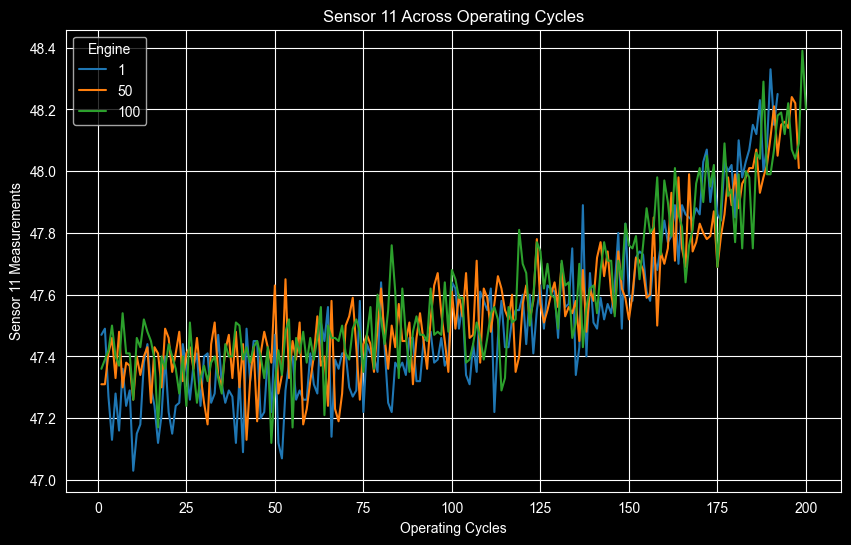

In [40]:
# hue: have 3 engines so use colors to distinguish engines
# ax=ax: connect Seaborn plot to Matplotlib plotting area

selected_engines = data[
    data["unit_number"].isin([1, 50, 100])
]

fig, ax = plt.subplots(figsize = (10,6))

sns.lineplot(
    data=selected_engines,
    x="time_in_cycles",
    y="sensor_11",
    hue="unit_number",
    palette="tab10",
    ax=ax
)

ax.set_title("Sensor 11 Across Operating Cycles")
ax.set_xlabel("Operating Cycles")
ax.set_ylabel("Sensor 11 Measurements")
ax.legend(title="Engine")

plt.show()

**Observations**

- Within each displayed engine, sensor 11 generally increases as the recorded operating cycles progress.
- The upward pattern becomes more noticeable during the later portion of the trajectories.
- A broadly similar pattern appears across the three example engines.
- If lower sensor 11 value => more RUL
- If higher sensor 11 value => less RUl
- If this pattern appear consistently a full training dataset, a model may be able to use this relationship as one signal for RUL prediction.
- This plot alone does not prove that a higher sensor 11 value always means greater degradation or lower RUL. The relationship must be examined across all engines and validated on engines not used for model training.
- Sensor 11 should be considered together with other sensor measurements, trends, and operating settings rather than used as a standalone indicator.
- The engines are aligned by cycle since operation began, not by RUL. Because the engines have different trajectory lengths, the same cycle number does not necessarily represent the same health stage for every engine.

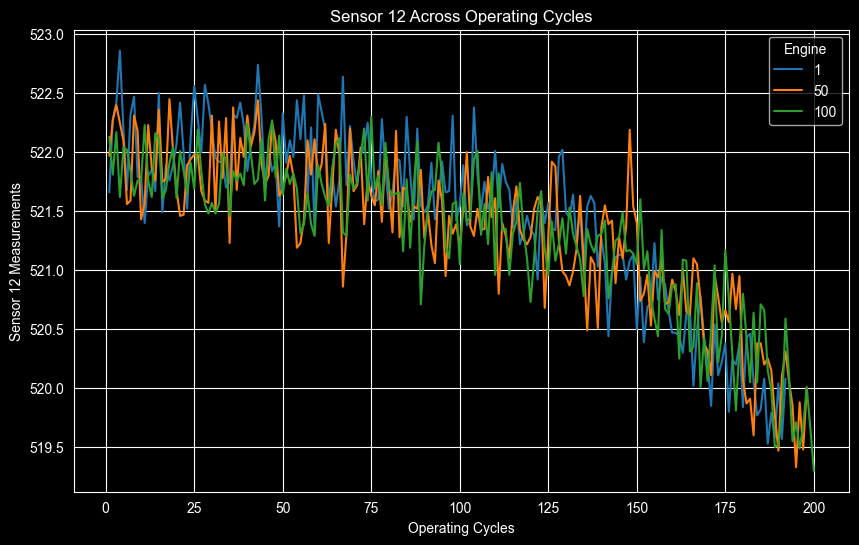

In [41]:
# hue: have 3 engines so use colors to distinguish engines
# ax=ax: connect Seaborn plot to Matplotlib plotting area

selected_engines = data[
    data["unit_number"].isin([1, 50, 100])
]

fig, ax = plt.subplots(figsize = (10,6))

sns.lineplot(
    data=selected_engines,
    x="time_in_cycles",
    y="sensor_12",
    hue="unit_number",
    palette="tab10",
    ax=ax
)

ax.set_title("Sensor 12 Across Operating Cycles")
ax.set_xlabel("Operating Cycles")
ax.set_ylabel("Sensor 12 Measurements")
ax.legend(title="Engine")

plt.show()

**Observation**
- Sensor 12 generally decreases as operating cycles increase
- The decline becomes more noticeable during later cycles
- Despite measurement noise, the three selected engines exhibit similar overall behavior.
- Sensor 12 moves in the opposite direction from sensor 11, but both appear to contain degradation-related information.

**Observation**
**Just general association between sensor 11 and 12**
**Not guaranteed rule for every row**
- Sensor 11 rising + Sensor 12 falling → possibly approaching end of life
- Earlier health stage:
Sensor 11 is relatively low +
Sensor 12 is relatively high
=> RUL is relatively high
- Later health stage:
Sensor 11 is relatively high +
Sensor 12 is relatively low
=> RUL is relatively low


## Exploration summary
- FD001 contains 20,631 observations from 100 simulated aircraft turbofan engines.
- Engine lifetimes range from 128 to 362 cycles, with a median of 199 cycles.
- The lifetime distribution is right-skewed because a small number of engines have substantially longer trajectories.
- FD001 represents a single operating condition. Its first two operating settings vary within narrow ranges, while the third is constant.
- Sensors 1, 5, 10, 16, 18, and 19 are constant in FD001, while sensor 6 is nearly constant.
- Sensor 11 generally increases with operating cycles, whereas sensor 12 generally decreases.
- The observed sensor trends suggest that some measurements contain useful degradation information for later RUL prediction.

## Data cleaning assessment
Before changing the dataset, we check for identificable data quality problems.
The original files under "data/raw/" remain unchanged

In [42]:
duplicate_count=data.duplicated(
    subset=["unit_number","time_in_cycles"]
).sum()

print(f"Duplicate engine-cycle records: {duplicate_count}")

Duplicate engine-cycle records: 0


- No duplicate "unit_number" and "time_in_cycle" combinations were found
- Therefore, no duplicate rows were removed

In [43]:
# For every engine, cycles should:
# - Begin at cycle 1
# - Increase one cycle at a time
# - Have no gaps or incorrect ordering

starting_cycles = data.groupby("unit_number")["time_in_cycles"].min()


# .diff(): subtract each cycle from the previous cycle in the same engine

# Engine 1 has cycles: 1,2,3,4
# .diff(): Nan, 1, 1, 1
# Because engine "increase 1 cycle at a time" => valid

# Engine 2 has cycles: 1,2,4,5
# .diff(): Nan, 1, 2, 1
# Because in here cycles increase 2 => Invalid

# Engine 3 has cycles: 1,2,2,3
#.diff(): Nan, 1, 0, 1
# Because in cycle have to increase 1 but have 0 => duplicate => Invalid

cycle_differences = (
    data.groupby("unit_number")["time_in_cycles"]
    .diff()
    .dropna()
)

# 2 boolean masks then .sum()
invalid_start_count = (starting_cycles !=1).sum()
invalid_step_count = (cycle_differences !=1).sum()

print(f"Engines not starting at cycle 1: {invalid_start_count}")

print(f"Invalid cycle steps: {invalid_step_count}")

Engines not starting at cycle 1: 0
Invalid cycle steps: 0


- All engines begin at cycle 1
- Every engine's cycles sequence increases consecutively without  gaps
- No cycle reordering or correction was required

### Identifier and cycle validity
- Engine identifiers and cycle numbers should be positive integers

In [44]:
print(data[["unit_number","time_in_cycles"]].dtypes)

invalid_unit_count = (data["unit_number"] <= 0).sum()
invalid_cycle_count = (data["time_in_cycles"] <= 0).sum()

print(f"Invalid unit numbers: {invalid_unit_count}")
print(f"Invalid cycle numbers: {invalid_cycle_count}")

unit_number       int64
time_in_cycles    int64
dtype: object
Invalid unit numbers: 0
Invalid cycle numbers: 0


- Engine identifiers and cycle numbers use integer data types
- All identifiers and cycle values are positive, so no corrections are required

### Infinite values check

In [45]:
import numpy as np

# select only columns contain numeric data
numeric_data = data.select_dtypes(include="number")

# convert pandas DataFrame to numpy array

# array([[1,10.5],[2,4]])
# which is a matrix [ 1   10.5]
#                   [ 2     4 ]

# check if these number are positive/negative infinite

# [False   False ]
# [False   False ]

# if True, converts to 1 then sum()
infinite_value_count = np.isinf(numeric_data.to_numpy()).sum()

print(f"Infinite numeric values: {infinite_value_count}")

Infinite numeric values: 0


### Why check infinite values?
- Summary statistics can become useless
- Metrics such as RMSE can become infinite
- One bad value can spread through later calculations

### Cleaning conclusion
## Cleaning conclusion

The FD001 training dataset contains:

- No missing values
- No infinite numeric values
- No duplicate engine-cycle records
- No invalid engine identifiers or cycle numbers
- No cycle gaps or ordering problems

Therefore, no rows were removed, imputed, reordered, or otherwise modified. The original files remain unchanged under `data/raw/`.

Constant and near-constant sensors were retained because removing them is a feature-selection decision for a later milestone, not a required data-cleaning correction.

Because no transformations were necessary, a duplicate cleaned dataset was not saved under `data/interim/`.